1) Создать качественный датасет для учителя-LLM
2) Создать качественный датасет для ученика-LLM
3) Обучить ученика-LLM

20К - для обучения
5K - для тестов

In [ ]:
CMAKE_ARGS="-DLLAMA_METAL=on"
!pip install sentence_transformers
!pip install langchain_text_splitters
!pip install transformers torch accelerate bitsandbytes
!pip install rank_bm25

# !pip install faiss-gpu-cu12 # *
!pip install faiss-cpu # if * doesnt work locally
!pip install llama-cpp-python

  Using cached llama_cpp_python-0.3.20.tar.gz (59.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached diskcache-5.6.3-py3-none-any.whl.metadata (20 kB)
Using cached diskcache-5.6.3-py3-none-any.whl (45 kB)
  Created wheel for llama-cpp-python: filename=llama_cpp_python-0.3.20-py3-none-macosx_26_0_arm64.whl size=11685134 sha256=ce177e26ff90c0f023239847a5bd70e1e448fb3fa6d189584f376ce35dedcabd
  Stored in directory: /Users/philippplotnikov/Library/Caches/pip/wheels/54/af/76/8c15ef256bcc7c70e0b033c10929b08aae811ef1eac47c6764
Successfully built llama-cpp-python
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [llama-cpp-python][llama-cpp-python]


In [3]:
!git clone https://github.com/chipslays/russian-recipes-parser.git

Cloning into 'russian-recipes-parser'...
remote: Enumerating objects: 14584, done.
remote: Counting objects: 100% (14584/14584), done.
remote: Compressing objects: 100% (1592/1592), done.
remote: Total 14584 (delta 12973), reused 14580 (delta 12971), pack-reused 0 (from 0)
Receiving objects: 100% (14584/14584), 18.55 MiB | 16.41 MiB/s, done.
Resolving deltas: 100% (12973/12973), done.


In [1]:
import os

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [2]:
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import sentence_transformers.losses as losses
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from langchain_text_splitters import RecursiveCharacterTextSplitter
import faiss
import numpy as np
from rank_bm25 import BM25Okapi
import re
from huggingface_hub import login

import json
import glob
from io import StringIO
import gc
from typing import Literal, Optional, Callable
from tqdm import tqdm
from numpy.typing import NDArray
import random
import copy
import datetime
import math
import traceback
import matplotlib.pyplot as plt
from collections import defaultdict
from llama_cpp import Llama


In [3]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device: Literal['mps', 'cpu'] = 'mps' if torch.backends.mps.is_available() else 'cpu'
device = 'cpu'
batch_size = 60
print(f"Используем устройство: {device}")

Используем устройство: cpu


In [ ]:
COLAB_HUGGING_FACE_ACCESS_TOKEN = "" # your token
login(token=COLAB_HUGGING_FACE_ACCESS_TOKEN)

In [5]:
with open('recipes.json', 'r', encoding='utf-8') as f:
    parsed_recipe_list = json.load(f)

print(f"Загружено {len(parsed_recipe_list)} рецептов")

Загружено 13702 рецептов


In [7]:
recipe_list_path = "russian-recipes-parser/storage/recipes/[0-9][0-9][0-9]/*.json"
parsed_recipe_list = []

recipe_file_list = glob.glob(recipe_list_path)
print(f"Найдено {len(recipe_file_list)} файлов рецептов для обработки.")
for step_index, filepath in tqdm(enumerate(recipe_file_list), total=len(recipe_file_list), desc="Обработка рецептов"):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            recipe_data = json.load(f)
        parsed_recipe = {
            "name": recipe_data.get('title', ''),
            "ingredients": recipe_data.get('ingredients', []),
            "instruction": recipe_data.get('instruction', []),
            "full_text": "",
        }
        full_recipe_text = StringIO()
        recipe_title = f"Название рецепта: {parsed_recipe['name']}\n\n"
        full_recipe_text.write(recipe_title)
        ingredients_data_list = parsed_recipe['ingredients']
        if isinstance(ingredients_data_list, list) and ingredients_data_list:
            ingredients_data = ingredients_data_list[0]
            full_recipe_text.write(f"{ingredients_data.get('name', '')}:\n")
            for step_index, ingredient in enumerate(ingredients_data.get('list', [])):
                full_recipe_text.write(f"{step_index + 1}) {ingredient.get('name', '')} {ingredient.get('value', '')} {ingredient.get('type', '')}\n")
        full_recipe_text.write(f"\nИнструкции по приготовлению:\n")
        for step_index, instruction_data in enumerate(recipe_data.get('instruction', [])):
          full_recipe_text.write(f"{step_index + 1}) {instruction_data.get('text', '')}\n")
        parsed_recipe["full_text"] = full_recipe_text.getvalue()
        parsed_recipe_list.append(parsed_recipe)
        if step_index and step_index % 1000 == 0:
            gc.collect()
    except Exception as e:
        print(f"Ошибка при обработке файла {filepath}: {e}")

print(f"Загружено {len(parsed_recipe_list)} рецептов.")


Найдено 13702 файлов рецептов для обработки.


Обработка рецептов: 100%|██████████| 13702/13702 [00:01<00:00, 9798.02it/s]

Загружено 13702 рецептов.


In [ ]:
print("\n--- Пример рецепта ---")
for retriever_index in range(5):
    parsed_recipe = parsed_recipe_list[retriever_index]
    print(parsed_recipe["full_text"])


--- Пример рецепта ---
Название рецепта: Плов с маринованной говядиной в мультиварке

Ингредиенты на 6 порции:
1) говядина 550 г
2) рис длиннозерный 370 г
3) лук белый 3 шт.
4) морковь 3 шт.
5) чеснок 4-5 зубчиков
6) масло растительное None None
7) приправы None None
8) соль None None

Инструкции по приготовлению:
1) Основной продукт очистить от пленок, нарезать кусками.
2) Мясо залить растительным маслом с приправами на два часа.
3) Влить растительное масло в чашу мультиварки, выставить режим «Жарка» на сорок минут.
4) В течение половины этого времени готовить мясо.
5) Далее всыпать белый лук, нарезанный кубиками, бруски сладкой моркови.
6) Все вместе жарить до окончания программы без крышки.
7) Влить горячую воду, всыпать соль и специи, нарезанный чеснок, выставить режим «Тушение» на пятьдесят минут.
8) В последнюю очередь всыпать промытый рис, влить полтора стакана горячей воды.
9) Продукты не перемешивать.
10) Блюдо тушить еще сорок минут.

Название рецепта: Плов с куриным филе и 

In [30]:
output_filename = 'recipes.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(parsed_recipe_list, f, ensure_ascii=False, indent=2)

print(f"Сохранено {len(parsed_recipe_list)} рецептов в {output_filename}")


Сохранено 13702 рецептов в recipes.json


In [6]:
with open('recipe_chunks.json', 'r', encoding='utf-8') as f:
    train_chunk_list = json.load(f)

print(f"Загружено {len(train_chunk_list)} чанков")

Загружено 95516 чанков


In [8]:
class RecipeChunker:
    def chunk_recipe(self, parsed_recipe, max_chunk_size=512):
      chunk_list = []
      parsed_recipe_name = parsed_recipe['name']

      # Уровень 1: Целый рецепт (глобальный контекст)
      chunk_list.append({
        'recipe_name': parsed_recipe_name,
        'scale': 'full',
        'text': parsed_recipe['full_text'],
      })

      # Уровень 2: Секции (ингредиенты)
      if parsed_recipe['ingredients']:
        ingredient_list = parsed_recipe['ingredients'][0]
        ingredient_text = StringIO()
        ingredient_text.write(f"Ингредиенты для рецепта \"{parsed_recipe_name}\":\n")
        for step_index, ingredient in enumerate(ingredient_list['list']):
          ingredient_text.write(f"{step_index + 1}) {ingredient['name']} {ingredient['value']} {ingredient['type']}\n")
        chunk_list.append({
          'recipe_name': parsed_recipe_name,
          'scale': 'ingredients',
          'text': ingredient_text.getvalue()
        })

      # Уровень 3: Отдельные шаги
      if parsed_recipe['instruction']:
        splitter = RecursiveCharacterTextSplitter(
          chunk_size=max_chunk_size,
          chunk_overlap=30,
          separators=[". ", ", ", " "]
        )
        instruction_text_prefix = f"Инструкции для рецепта \"{parsed_recipe_name}\":\n"
        for step_index, instruction_data in enumerate(parsed_recipe['instruction']):
          step_number = step_index + 1
          instruction_text = StringIO()
          instruction_text.write(instruction_text_prefix)
          instruction_text.write(f"{step_number}) {instruction_data['text']}\n")
          if instruction_text.tell() <= max_chunk_size:
            chunk_list.append({
              'recipe_name': parsed_recipe_name,
              'scale': 'step',
              'step_number': step_number,
              'text': instruction_text.getvalue(),
            })
            continue
          instruction_text_chunk_list = splitter.split_text(instruction_text.getvalue())
          for substep_index, instruction_text_chunk in enumerate(instruction_text_chunk_list):
            chunk_list.append({
              'recipe_name': parsed_recipe_name,
              'scale': 'substep',
              'text': instruction_text_chunk,
              'step_number': step_number,
              'substep_number': substep_index + 1,
            })
      return chunk_list


In [ ]:
recipe_chunker = RecipeChunker()
train_chunk_list = []
for retriever_index, parsed_recipe in tqdm(enumerate(parsed_recipe_list), total=len(parsed_recipe_list), desc="Создание чанков рецептов"):
  train_chunk_list.extend(recipe_chunker.chunk_recipe(parsed_recipe))
  if retriever_index and retriever_index % 1000 == 0:
    gc.collect()

print(f"Создано {len(train_chunk_list)} чанков разного масштаба")
for retriever_index in range(5):
  train_chunk = train_chunk_list[retriever_index]
  print(json.dumps(train_chunk, ensure_ascii=False, indent=2))

Создание чанков рецептов: 100%|██████████| 13702/13702 [00:06<00:00, 2074.33it/s]

Создано 95516 чанков разного масштаба
{
  "recipe_name": "Плов с маринованной говядиной в мультиварке",
  "scale": "full",
  "text": "Название рецепта: Плов с маринованной говядиной в мультиварке\n\nИнгредиенты на 6 порции:\n1) говядина 550 г\n2) рис длиннозерный 370 г\n3) лук белый 3 шт.\n4) морковь 3 шт.\n5) чеснок 4-5 зубчиков\n6) масло растительное None None\n7) приправы None None\n8) соль None None\n\nИнструкции по приготовлению:\n1) Основной продукт очистить от пленок, нарезать кусками.\n2) Мясо залить растительным маслом с приправами на два часа.\n3) Влить растительное масло в чашу мультиварки, выставить режим «Жарка» на сорок минут.\n4) В течение половины этого времени готовить мясо.\n5) Далее всыпать белый лук, нарезанный кубиками, бруски сладкой моркови.\n6) Все вместе жарить до окончания программы без крышки.\n7) Влить горячую воду, всыпать соль и специи, нарезанный чеснок, выставить режим «Тушение» на пятьдесят минут.\n8) В последнюю очередь всыпать промытый рис, влить полт

In [ ]:
output_filename = 'recipe_chunks.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(train_chunk_list, f, ensure_ascii=False, indent=2)

print(f"Сохранено {len(train_chunk_list)} чанков в {output_filename}")


Сохранено 95516 чанков в recipe_chunks.json


In [ ]:
# 3352
class RecipeQuestionGenerator:
    def __init__(self, model_name="Qwen/Qwen2.5-7B-Instruct"):
        # TODO: it needs to read about it
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=bnb_config,
            device_map="cuda:0",
            trust_remote_code=True,
            use_cache=True
        )
        self.model.eval()
        self.model = torch.compile(self.model, mode="reduce-overhead")
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token


    def generate_question_list(self, recipe_text: str, question_amount=3) -> list[str]:
        question_prompt = self._create_question_prompt(recipe_text, question_amount)
        tokenizer_output = self.tokenizer(question_prompt, return_tensors="pt", truncation=True, max_length=2048).to(self.model.device)
        with torch.inference_mode():
            model_output = self.model.generate(
                **tokenizer_output,
                max_new_tokens=256,
                temperature=0.7,
                do_sample=True,
                top_p=0.9,
                top_k=50,
                repetition_penalty=1.05
            )
        model_response = self.tokenizer.decode(model_output[0], skip_special_tokens=True)
        return self._extract_question_list(model_response, question_amount)


    def _extract_question_list(self, model_response: str, question_amount: int) -> list[str]:
        question_list = []
        question = ""
        if "Вопрос 1:" in model_response:
            model_response = model_response.split("Вопрос 1:")[-1]
            for index in range(1, question_amount + 1):
                current_marker = f"Вопрос {index}:"
                next_marker = f"Вопрос {index+1}:" if index + 1 <= question_amount else None
                if next_marker and next_marker in model_response:
                    question, model_response = model_response.split(next_marker, 1)
                    question = question.replace(current_marker, "").strip()
                else:
                    question = model_response.replace(current_marker, "").strip()
                    if index == question_amount - 1:
                        question = model_response.strip()
                question_list.append(question)
        question_list = [question.strip() for question in question_list if question and '?' in question]
        return question_list[:question_amount]

    def _create_question_prompt(self, recipe_text: str, question_amount: int = 3) -> str:
        return f"""Ты — ассистент, который помогает обучать систему поиска рецептов. Твоя задача — придумать {question_amount} разнообразных вопросов, на которые отвечает данный текст.

Правила:
1. Вопросы должны быть краткими и естественными (как их мог бы задать пользователь)
2. Каждый вопрос должен быть уникальным и затрагивать разные аспекты текста
3. Используй информацию ТОЛЬКО из текста
4. Не задавай вопросы, требующие знаний вне текста

Текст:
{recipe_text}

Отвечай строго в формате:
Вопрос 1: [первый вопрос]
Вопрос 2: [второй вопрос]
Вопрос 3: [третий вопрос]

Не добавляй ничего кроме вопросов в этом формате."""


In [ ]:
question_generator = RecipeQuestionGenerator()
question_list = []
part_of_chunk_list = train_chunk_list[3000:6000]
for retriever_index, train_chunk in tqdm(enumerate(part_of_chunk_list), total=len(part_of_chunk_list), desc="Генерация вопросов для чанков рецептов"):
  if train_chunk['scale'] != 'full':
    continue
  train_chunk['questions'] = question_generator.generate_question_list(train_chunk['text'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Генерация вопросов для чанков рецептов: 100%|██████████| 3000/3000 [51:22<00:00,  1.03s/it]  


In [ ]:
output_filename = 'recipe_chunks_with_questions_2.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(part_of_chunk_list, f, ensure_ascii=False, indent=2)

print(f"Сохранено {len(part_of_chunk_list)} чанков в {output_filename}")


In [5]:
input_filename = 'recipe_chunks_with_questions_1.json'
with open(input_filename, 'r', encoding='utf-8') as f:
    train_chunk_list = json.load(f)

print(f"Загружено {len(train_chunk_list)} чанков")


Загружено 3000 чанков


In [6]:
input_filename = 'recipe_chunks_with_questions_2.json'
with open(input_filename, 'r', encoding='utf-8') as f:
    eval_chunk_list = json.load(f)
print(f"Загружено {len(eval_chunk_list)} чанков")

Загружено 1499 чанков


In [7]:
class BM25Model:
    def __init__(self, chunk_list: list):
        text_chunk_list = [chunk['text'] for chunk in chunk_list]
        token_list = []
        for chunk in text_chunk_list:
            word_list = re.findall(r'\w+', chunk.lower())
            token_list.append(word_list)
        self.model = BM25Okapi(token_list)


    def search(self, question: str, k: int) -> tuple[torch.Tensor, torch.Tensor]:
        tokenized_query = re.findall(r'\w+', question.lower())
        score_list = self.model.get_scores(tokenized_query)
        # TODO: dont like the copy
        index_list = torch.tensor(np.argsort(score_list)[-k:][::-1].copy())
        return index_list, torch.tensor(score_list)[index_list]

In [8]:
class DenseModel:
    def __init__(self, chunk_list: list, model_name="deepvk/USER2-small", device: Literal['cpu', 'cuda', 'mps']='cuda'):
        self.model = SentenceTransformer(model_name, device=device)
        text_chunk_list = [chunk['text'] for chunk in chunk_list]
        self.embedding_list = self.model.encode(
            text_chunk_list,
            prompt_name="search_document",
            show_progress_bar=True,
            batch_size=batch_size
        )
        faiss.normalize_L2(self.embedding_list)
        self.index = faiss.IndexFlatIP(self.embedding_list.shape[1])
        self.index.add(self.embedding_list.astype('float32')) # type: ignore


    def search(self, question: str, k: int) -> tuple[torch.Tensor, torch.Tensor]:
        query_embedding = self.model.encode([question], prompt_name="search_query")
        faiss.normalize_L2(query_embedding)
        scores, indices = self.index.search(query_embedding.astype('float32'), k) # type: ignore
        return torch.tensor(indices[0]), torch.tensor(scores[0])

In [9]:
class TeacherRetrieverPool(nn.Module):
    def __init__(self, teacher_amount=2, top_k=12, rrf_K=60):
        super().__init__()
        self.RRF_K = rrf_K
        self.top_k = top_k
        self.total_teacher_amount = teacher_amount
        self.teacher_model_dict = {}
        self.weight_tensor = nn.Parameter(torch.ones(teacher_amount))


    def forward(
        self,
        query_data_batch: list[tuple[str, torch.Tensor, torch.Tensor]] # [(str, index_tensor[current_teacher_amount, top_k], ranking_tensor[current_teacher_amount, top_k])]
    ) -> tuple[list[str], torch.Tensor]: # (list of query, positive_document_index_tensor)
        device = next(self.parameters()).device
        batch_size = len(query_data_batch)
        query_list = []    
        fuse_ranked_index_tensor_list = []

        for query_data in query_data_batch:
            query_list.append(query_data[0])
            ranked_index_tensor = self.get_fuse_ranked_index_tensor(query_data[1], query_data[2])
            fuse_ranked_index_tensor_list.append(ranked_index_tensor)
        fused_ranked_index_batch = torch.stack(fuse_ranked_index_tensor_list)  # [batch, top_k]
        
        positive_document_position_tensor = torch.randint(0, 5, (batch_size,))
        positive_document_index_tensor = fused_ranked_index_batch[torch.arange(batch_size), positive_document_position_tensor]
        return query_list, positive_document_index_tensor.to(device)


    def add_teacher(self, teacher_name: str, teacher_model):
        if len(self) < self.total_teacher_amount:
            self.teacher_model_dict[teacher_name] = teacher_model


    def get_index_and_ranking_tensor(self, question_list: list[str]) -> tuple[torch.Tensor, torch.Tensor]:
        index_tensor = torch.zeros((len(question_list), self.total_teacher_amount, self.top_k), dtype=torch.long)
        ranking_tensor = torch.zeros((len(question_list), self.total_teacher_amount, self.top_k))
        for question_index, question in enumerate(question_list):
            for teacher_index, (_, teacher_model) in enumerate(self.teacher_model_dict.items()):
                teacher_index_tensor, teacher_score_tensor = teacher_model.search(question, self.top_k)
                index_tensor[question_index, teacher_index] = teacher_index_tensor
                ranking_tensor[question_index, teacher_index] = teacher_score_tensor
        return index_tensor, ranking_tensor


    # ranking_tensor shape is [current_teacher_amount, top_k]
    def get_fuse_ranked_index_tensor(self, index_tensor: torch.Tensor, ranking_tensor: torch.Tensor) -> torch.Tensor:
        teacher_weight_tensor = self.weight_tensor[:index_tensor.size(0)].view(-1, 1)  # [teacher_amount, 1]
        rrf_score_tensor = teacher_weight_tensor / (self.RRF_K + ranking_tensor)
        flat_index_tensor = index_tensor.flatten()       # [teacher_amount*top_k]
        flat_score_tensor = rrf_score_tensor.flatten()         # [teacher_amount*top_k]
        fused_score_tensor = torch.zeros(int(flat_index_tensor.max().item() + 1), dtype=torch.float)
        fused_score_tensor = fused_score_tensor.scatter_add(0, flat_index_tensor, flat_score_tensor)
        sorted_document_index_tensor = torch.argsort(fused_score_tensor, descending=True)
        return sorted_document_index_tensor
    

    def __len__(self) -> int:
        return len(self.teacher_model_dict)


In [11]:
class MultiNegativeLoss(nn.Module):
    def __init__(self, encoder, temperature=0.05):
        super().__init__()
        self.encoder = encoder
        self.temperature = temperature


    def forward(self, sentence_features, labels=None):
        query_features, positive_features = sentence_features
        query_embeddings = self.encoder(query_features)["sentence_embedding"] # [B, D]
        pos_embeddings   = self.encoder(positive_features)["sentence_embedding"]
        query_embeddings = F.normalize(query_embeddings, dim=1)
        pos_embeddings   = F.normalize(pos_embeddings, dim=1)
        scores = torch.matmul(query_embeddings, pos_embeddings.T) / self.temperature
        labels = torch.arange(scores.size(0), device=scores.device)
        return F.cross_entropy(scores, labels)


In [12]:
class PovaryoshkaRetriever(nn.Module):
  def __init__(
    self,
    document_list: list[str],
    teacher_retriever_pool: TeacherRetrieverPool,
    device: Literal['cpu', 'cuda', 'mps'] = 'cuda',
    encoder_name="deepvk/USER2-small",
    dtype="float32",
    temperature=0.05,
    matryoshka_dims=[384, 256, 128],
    nlist=100
  ):
    super().__init__()
    self.temperature = temperature
    self.document_list = document_list
    self.retriever_index = None
    self.DTYPE = dtype
    self.encoder = SentenceTransformer(encoder_name, device=device, model_kwargs={"dtype": dtype})
    base_encoder_loss = MultiNegativeLoss(self.encoder, temperature)
    self.encoder_loss = losses.MatryoshkaLoss(
      self.encoder,
      base_encoder_loss,
      matryoshka_dims
    )
    self.teacher_retriever_pool = teacher_retriever_pool
    self.NLIST = nlist


  def forward(
    self,
    batch_query_data: list[tuple[str, torch.Tensor, torch.Tensor]] # [(str, index_tensor[current_teacher_amount, top_k], ranking_tensor[current_teacher_amount, top_k])]
  ) -> torch.Tensor:
    assert self.document_list is not None, "Firstly, initialize document_list field"
    encoder_device = next(self.encoder.parameters()).device
    query_list, positive_chunk_index_tensor = self.teacher_retriever_pool(batch_query_data)
    positive_chunk_list = []

    for positive_chunk_index in positive_chunk_index_tensor:
      positive_chunk_list.append(
        self.document_list[positive_chunk_index.item()]
      )

    query_features = self.to_device(
      self.encoder.tokenize(query_list), encoder_device
    )
    positive_features = self.to_device(
      self.encoder.tokenize(positive_chunk_list), encoder_device
    )
    return self.encoder_loss(
      sentence_features=[query_features, positive_features],
      labels=None
    )


  def to_device(self, features, device):
    return {k: v.to(device) for k, v in features.items()}


  def get_encoded_query_tensor(
    self,
    query_list: list[str],
    is_normalize=True
  ) -> torch.Tensor:
    self.eval()
    with torch.inference_mode():
      return self._get_encoded_text_tensor(query_list, True, is_normalize)


  def get_encoded_document_tensor(
    self,
    document_list: list[str],
    is_normalize=True
  ) -> torch.Tensor:
    self.eval()
    with torch.inference_mode():
      return self._get_encoded_text_tensor(document_list, is_normalize)
      

  def _get_encoded_text_tensor(
    self,
    text_list: list[str],
    is_query=False,
    is_normalize=True
  ) -> torch.Tensor:
    embedding_text_list = self.encoder.encode(
      text_list,
      prompt_name="search_query" if is_query else "search_document",
      convert_to_tensor=True,
      truncate_dim=384
    )
    if is_normalize:
      embedding_text_list = F.normalize(embedding_text_list, dim=1)
    return embedding_text_list


  def build_index(self):
    self.eval()
    with torch.inference_mode():
      # TODO: Check about type
      embedding_list = self._get_encoded_text_tensor(self.document_list).cpu().numpy().astype('float32') 
    embedding_list = np.ascontiguousarray(embedding_list)
    embedding_dimension = embedding_list.shape[1]
    retriever_index = faiss.IndexFlatIP(embedding_dimension)
    retriever_index.add(embedding_list) # type: ignore
    self.retriever_index = retriever_index


  def search(
    self,
    query_list: list[str],
    top_k=15
  ) -> list[list[int]]:
    assert self.retriever_index is not None, "Firstly call build_index()"
    self.eval()
    with torch.inference_mode():
      query_embedding_list = self._get_encoded_text_tensor(
        query_list,
        True
      ).cpu().numpy().astype('float32')
    _, indices_list = self.retriever_index.search(query_embedding_list, top_k) # type: ignore
    return indices_list


  def save(self, path: str):
    self.encoder.save(path)


  def load(self, path: str):
    self.encoder = SentenceTransformer(path)


In [13]:
pruned_train_chunk_list = []
for train_chunk in train_chunk_list:
    if 'questions' not in train_chunk:
        continue
    if not train_chunk['questions']:
        continue
    pruned_train_chunk_list.append(train_chunk)

pruned_eval_chunk_list = []
for train_chunk in eval_chunk_list:
    if 'questions' not in train_chunk:
        continue
    if not train_chunk['questions']:
        continue
    pruned_eval_chunk_list.append(train_chunk)


In [14]:
output_filename = 'pruned_recipe_chunks_with_questions_1.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(pruned_train_chunk_list, f, ensure_ascii=False, indent=2)

print(f"Сохранено {len(pruned_train_chunk_list)} чанков в {output_filename}")


Сохранено 406 чанков в pruned_recipe_chunks_with_questions_1.json


In [15]:
output_filename = 'pruned_recipe_chunks_with_questions_2.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    json.dump(pruned_eval_chunk_list, f, ensure_ascii=False, indent=2)

print(f"Сохранено {len(pruned_eval_chunk_list)} чанков в {output_filename}")


Сохранено 173 чанков в pruned_recipe_chunks_with_questions_2.json


In [16]:
teacher_retriever_pool = TeacherRetrieverPool(1, top_k=5)
pruned_train_chunk_list = pruned_train_chunk_list[:400]
pruned_eval_chunk_list = pruned_eval_chunk_list[:160]
pruned_common_chunk_list = pruned_train_chunk_list + pruned_eval_chunk_list
teacher_retriever_pool.add_teacher('bm25', BM25Model(pruned_common_chunk_list))
teacher_retriever_pool.add_teacher('dense', DenseModel(pruned_common_chunk_list, device='mps'))


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Compiling the model with `torch.compile` and using a `torch.mps` device is not supported. Falling back to non-compiled mode.


In [206]:
print(pruned_train_chunk_list[0])

{'recipe_name': 'Плов с маринованной говядиной в мультиварке', 'scale': 'full', 'text': 'Название рецепта: Плов с маринованной говядиной в мультиварке\n\nИнгредиенты на 6 порции:\n1) говядина 550 г\n2) рис длиннозерный 370 г\n3) лук белый 3 шт.\n4) морковь 3 шт.\n5) чеснок 4-5 зубчиков\n6) масло растительное None None\n7) приправы None None\n8) соль None None\n\nИнструкции по приготовлению:\n1) Основной продукт очистить от пленок, нарезать кусками.\n2) Мясо залить растительным маслом с приправами на два часа.\n3) Влить растительное масло в чашу мультиварки, выставить режим «Жарка» на сорок минут.\n4) В течение половины этого времени готовить мясо.\n5) Далее всыпать белый лук, нарезанный кубиками, бруски сладкой моркови.\n6) Все вместе жарить до окончания программы без крышки.\n7) Влить горячую воду, всыпать соль и специи, нарезанный чеснок, выставить режим «Тушение» на пятьдесят минут.\n8) В последнюю очередь всыпать промытый рис, влить полтора стакана горячей воды.\n9) Продукты не пер

In [17]:
# TODO: Think do we need here to add context ?
train_ranked_chunk_list = []
for train_chunk in pruned_train_chunk_list:
    # TODO: not only the first
    first_question = f'Контекст: {train_chunk['recipe_name']}\n\n{train_chunk['questions'][0]}'
    train_chunk['questions'][0] = first_question
    index_tensor, ranked_index_tensor = teacher_retriever_pool.get_index_and_ranking_tensor([first_question])
    train_chunk['index_tensors'] = index_tensor
    train_chunk['ranking_tensors'] = ranked_index_tensor
    train_ranked_chunk_list.append(train_chunk)

eval_ranked_chunk_list = []
for train_chunk in pruned_eval_chunk_list:
    # TODO: not only the first
    first_question = f'Контекст: {train_chunk['recipe_name']}\n\n{train_chunk['questions'][0]}'
    train_chunk['questions'][0] = first_question
    index_tensor, ranked_index_tensor = teacher_retriever_pool.get_index_and_ranking_tensor([first_question])
    train_chunk['index_tensors'] = index_tensor
    train_chunk['ranking_tensors'] = ranked_index_tensor
    eval_ranked_chunk_list.append(train_chunk)

torch.save(train_ranked_chunk_list, 'recipe_chunks_with_ranking_tensors_1.pth')
torch.save(eval_ranked_chunk_list, 'recipe_chunks_with_ranking_tensors_2.pth')

In [18]:
train_ranked_chunk_list = torch.load('recipe_chunks_with_ranking_tensors_1.pth')
for train_chunk in train_ranked_chunk_list:
    train_chunk['index_tensors'] = train_chunk['index_tensors'].to(device)
    train_chunk['ranking_tensors'] = train_chunk['ranking_tensors'].to(device)
print(len(train_ranked_chunk_list))

400


In [24]:
print(train_ranked_chunk_list[0]['index_tensors'].shape)

torch.Size([1, 1, 5])


In [19]:
eval_ranked_chunk_list = torch.load('recipe_chunks_with_ranking_tensors_2.pth')
for eval_chunk in eval_ranked_chunk_list:
    eval_chunk['index_tensors'] = eval_chunk['index_tensors'].to(device)
    eval_chunk['ranking_tensors'] = eval_chunk['ranking_tensors'].to(device)
print(len(eval_ranked_chunk_list))

160


In [19]:
class RetrieverDataset(Dataset):
    def __init__(self, ranked_chunk_list):
        self.ranked_chunk_list = ranked_chunk_list


    def __len__(self) -> int:
        return len(self.ranked_chunk_list)

    # TODO
    def __getitem__(self, index: int) -> tuple[str, torch.Tensor, torch.Tensor]:
        ranked_chunk = self.ranked_chunk_list[index]
        return ranked_chunk['questions'][0], ranked_chunk['index_tensors'][0], ranked_chunk['ranking_tensors'][0]


In [20]:
def create_povaryoshka_retriever_fn(teacher_retriever_pool: TeacherRetrieverPool):
    current_epoch_number = 0

    def povaryoshka_retriever_collate_fn(
        query_data_batch: list[tuple[str, torch.Tensor, torch.Tensor]] # [(str, index_tensor[teacher_amount, top_k], ranking_tensor[teacher_amount, top_k])]
    ) -> list[tuple[str, torch.Tensor, torch.Tensor]]: # [(str, index_tensor[current_teacher_amount, top_k], ranking_tensor[current_teacher_amount, top_k])]
        teacher_retriever_amount = 1 if current_epoch_number == 0 else len(teacher_retriever_pool)
        updated_query_data_batch = []
        for query_data in query_data_batch:
            updated_query_data_batch.append(
                (query_data[0], query_data[1][:teacher_retriever_amount], query_data[2][:teacher_retriever_amount])
            )
        return updated_query_data_batch
    
    def set_current_epoch_number(value: int):
        nonlocal current_epoch_number
        current_epoch_number = value
    
    return povaryoshka_retriever_collate_fn, set_current_epoch_number


In [21]:
def compute_recall_at_k(
    retriever_model: PovaryoshkaRetriever,
    query_list: list[str],
    true_index_list: list[int],
    k=5
) -> float:
    retriever_model.eval()
    correct_amount = 0
    with torch.no_grad():
        retrieved_indices_list = retriever_model.search(query_list, top_k=k)
        for i in range(len(query_list)):
            if true_index_list[i] in retrieved_indices_list[i]:
                correct_amount += 1
    return correct_amount / len(query_list)


def copy_data_to_device(data, device):
  if torch.is_tensor(data):
    return data.to(device)
  elif isinstance(data, (list, tuple)):
    return [copy_data_to_device(elem, device) for elem in data]
  return data


def loss_plot(losses: list[float]):
  plt.plot(np.arange(len(losses)), losses)
  plt.title('Losses')
  plt.xlabel("epoch")
  plt.show()


def retriever_train_loop(
    retriever_model: PovaryoshkaRetriever,
    set_current_epoch_number: Callable[[int], None],
    train_dataloader,
    eval_dataloader,
    lr=1e-4,
    epoch_amount=10,
    device: Literal['cuda', 'cpu', 'mps']='cuda',
    l2_reg_alpha=0,
    optimizer_ctor=None,
    lr_scheduler_ctor=None,
    early_stopping_patience=10,
    k=5
):
    if optimizer_ctor is None:
        optimizer = torch.optim.Adam(retriever_model.parameters(), lr=lr, weight_decay=l2_reg_alpha)
    else:
        optimizer = optimizer_ctor(retriever_model.parameters(), lr=lr)

    if lr_scheduler_ctor is not None:
        lr_scheduler = lr_scheduler_ctor(optimizer)

    best_eval_loss = float('inf')
    retriever_model = retriever_model.to(device)
    best_retriever_model = copy.deepcopy(retriever_model)
    retriever_model.train()
    loss_list = []

    for epoch_index in range(epoch_amount):
        try:
            set_current_epoch_number(epoch_index)
            epoch_start = datetime.datetime.now()
            print(f'Эпоха {epoch_index}')
            retriever_model.train()
            mean_train_loss = 0
            train_batches_n = 0
            for train_batch in train_dataloader:
                train_batch = copy_data_to_device(train_batch, device)
                train_loss = retriever_model(train_batch)
                retriever_model.zero_grad()
                train_loss.backward()
                optimizer.step()
                mean_train_loss += train_loss.item()
                train_batches_n += 1

            mean_train_loss /= train_batches_n
            loss_list.append(mean_train_loss)
            print('Эпоха: {} итераций, {:0.2f} сек'.format(train_batches_n,
                                                           (datetime.datetime.now() - epoch_start).total_seconds()))

            if eval_dataloader is None:
                if lr_scheduler is not None:
                    lr_scheduler.step(mean_train_loss)
                continue

            retriever_model.eval()
            mean_eval_loss = 0
            eval_batches_n = 0
            eval_data = []
            with torch.no_grad():
                for eval_batch in eval_dataloader:
                    eval_batch = copy_data_to_device(eval_batch, device)
                    eval_data.extend(eval_batch)
                    eval_loss = retriever_model(eval_batch)
                    mean_eval_loss += float(eval_loss)
                    eval_batches_n += 1

            mean_eval_loss /= eval_batches_n
            print(f'Среднее значение функции потерь на валидации {mean_eval_loss}')

            # Move to another place maybe   
            retriever_model.build_index()
            with torch.no_grad():
                _, positive_document_index_tensor = retriever_model.teacher_retriever_pool(eval_data)
            recall_at_k = compute_recall_at_k(
                retriever_model,
                [chunk[0] for chunk in eval_data],
                positive_document_index_tensor.cpu().numpy().tolist(),
                k=k
            )
            print(f'Total query amount: {len(eval_data)}')
            print(f'Recall@{k}: {recall_at_k}')
                

            if mean_eval_loss < best_eval_loss:
                best_epoch_index = epoch_index
                best_eval_loss = mean_eval_loss
                best_retriever_model = copy.deepcopy(retriever_model)
                print('Новая лучшая модель!')
                torch.save(best_retriever_model.state_dict(), 'povaryoshka_retriever_model_weights.pth')
                print("Модель сохранена!")
            elif epoch_index - best_epoch_index > early_stopping_patience:
                print('Модель не улучшилась за последние {} эпох, прекращаем обучение'.format(
                    early_stopping_patience))
                break
            print()
        except KeyboardInterrupt:
            print('Досрочно остановлено пользователем')
            break
        except Exception as ex:
            print(f'Ошибка при обучении: {ex}\n{traceback.format_exc()}')
            break
    loss_plot(loss_list)
    if eval_dataloader is None:
        return retriever_model, None
    return best_retriever_model, best_eval_loss
    

In [20]:
common_document_list = [chunk['text'] for chunk in pruned_common_chunk_list]

Эпоха 0
Эпоха: 7 итераций, 91.34 сек
Среднее значение функции потерь на валидации 1.5198358694712322
Total query amount: 160
Recall@5: 0.55625
Новая лучшая модель!
Модель сохранена!

Эпоха 1
Эпоха: 7 итераций, 97.70 сек
Среднее значение функции потерь на валидации 1.19520898660024
Total query amount: 160
Recall@5: 0.5875
Новая лучшая модель!
Модель сохранена!

Эпоха 2
Эпоха: 7 итераций, 101.82 сек
Среднее значение функции потерь на валидации 1.1536296606063843
Total query amount: 160
Recall@5: 0.6125
Новая лучшая модель!
Модель сохранена!

Эпоха 3
Эпоха: 7 итераций, 90.47 сек
Среднее значение функции потерь на валидации 0.9823375344276428
Total query amount: 160
Recall@5: 0.65
Новая лучшая модель!
Модель сохранена!

Эпоха 4
Эпоха: 7 итераций, 94.70 сек
Среднее значение функции потерь на валидации 0.9285711248715719
Total query amount: 160
Recall@5: 0.70625
Новая лучшая модель!
Модель сохранена!

Эпоха 5
Эпоха: 7 итераций, 102.95 сек
Среднее значение функции потерь на валидации 0.939610

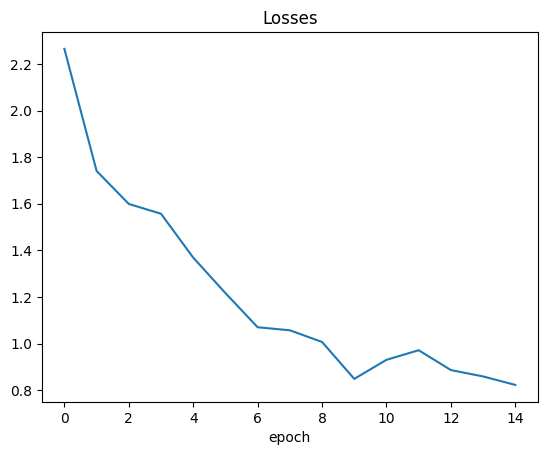

In [ ]:
train_dataset = RetrieverDataset(train_ranked_chunk_list)
povaryoshka_retriever_collate_fn, set_current_epoch_number = create_povaryoshka_retriever_fn(
  teacher_retriever_pool
)
train_dataloader = DataLoader(
  train_dataset,
  batch_size=batch_size,
  shuffle=True,
  collate_fn=povaryoshka_retriever_collate_fn,
  num_workers=0
)
eval_dataset = RetrieverDataset(eval_ranked_chunk_list)
eval_dataloader = DataLoader(
  eval_dataset,
  batch_size=batch_size,
  shuffle=True,
  collate_fn=povaryoshka_retriever_collate_fn,
  num_workers=0
)



llm_model = PovaryoshkaRetriever(
  common_document_list,
  teacher_retriever_pool,
  temperature=0.1,
  dtype='float32',
  nlist=1,
  device=device,
  matryoshka_dims=[384]
)

scheduler = lambda optim: \
    torch.optim.lr_scheduler.ReduceLROnPlateau(optim, patience=3, factor=0.43)
trained_retriever_model, _ = retriever_train_loop(
  llm_model,
  set_current_epoch_number,
  train_dataloader,
  eval_dataloader,
  lr_scheduler_ctor=scheduler,
  epoch_amount=15,
  device=device
)


In [ ]:
# Я сейчас готовлю пирог Киш Лорен. Подскажи, как готовится тесто для пирога?
question = input("Введите вопрос для поиска рецепта: ")
trained_retriever_model.build_index()
with torch.inference_mode():
    response = trained_retriever_model.search(
        [question],
        5
    )

for retrieved_list_index in response:
    for retrieved_index in retrieved_list_index:
        print(pruned_common_chunk_list[retrieved_index]['text'])
        print('---')

Название рецепта: Пирог Киш лорен с копченой курицей и сыром

Ингредиенты на 6 порции:
1) куриные окорочка копченые 300 г
2) сыр копченый 150 г
3) масло сливочное 120 г
4) сметана 120 г
5) мука 110 г
6) вода 30 мл
7) укроп 20 г
8) молоко ½ стакан
9) яйца 2 шт.

Инструкции по приготовлению:
1) В миску высыпать муку, добавить к ней кусочки сливочного масла комнатной температуры - перемешать. Добавить воды и снова перемешать. Завернуть тесто пленку и убрать в холодильник на 1 час.
2) Копченый сыр разделить на 2 части, одну часть нарезать соломкой, вторую мелко натереть. Ту что нарезана соломкой смешать с окороком и вбить 2 яйца. Добавить сметану и молоко - перемешать. Укроп мелко нарезать.
3) Тесто обильно посыпать мукой и раскатать. Выложить в форму для запекания формируя бортики. Тесто наколоть вилкой, залить начинкой, посыпать укропом и сверху тертым сыром. Ставим в духовку на 50 минут при температуре 180 градусов.

---
Название рецепта: Пирог Киш Лорен с томатами и моцареллой

Ингреди

In [21]:
llm_model = Llama(
    model_path="/Users/philippplotnikov/WorkingSpace/Coding/models/Qwen3-8B-Q4_K_M-Instruct.gguf",
    n_ctx=4096,        # контекст
    n_threads=8,       # под CPU
    n_gpu_layers=40,    # для M1 (ускорение через Metal)
    verbose=False
)

llama_context: n_ctx_seq (4096) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


In [22]:
def generate(prompt, max_new_tokens=1024, temperature=0.4, top_k=50, top_p=0.9, repeat_penalty=1.3, stop_tokens=None):
    output = llm_model(
        prompt,
        max_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        repeat_penalty=repeat_penalty,
        stop=stop_tokens
    )

    # Берём только сгенерированный текст
    text = output["choices"][0]["text"]

    # Обрезаем до первого stop-токена, если он есть
    if stop_tokens:
        for stop in stop_tokens:
            if stop in text:
                text = text.split(stop)[0]

    return text.strip()

In [23]:
class ContextManager:
    def __init__(self, max_history=5):
        self.user_contexts = {}  # user_id → список компактных документов
        self.max_history = max_history

    def add_context(self, user_id, doc_text):
        if user_id not in self.user_contexts:
            dish = generate(f"""
Ты — ассистент, который определяет название блюда из текста.

ПРАВИЛА:
- Ответь ТОЛЬКО названием блюда.
- Не добавляй пояснений.
- Не изменяй название блюда.
- Если блюдо не указано явно — ответь "Нет".
- Если блюд несколько — выбери основное (о котором больше всего информации).

Пример:

Текст:
Обсуждается Пирог Киш Лорен с томатами и моцареллой: тесто из муки, сливочного масла, сметаны и соли нужно охладить 1 час; пользователь интересуется начинкой.

Ответ (начинай здесь):
Пирог Киш Лорен с томатами и моцареллой
### Конец ответа

Теперь твой текст:

Текст:
{doc_text}

Ответ (начинай здесь):
""", stop_tokens=["### Конец ответа"])
            self.user_contexts[user_id] = {
                "summary": doc_text,
                "dish": dish
            }
            return
        prev_context = self.user_contexts[user_id]
        compact_prompt = f"""
Ты — ассистент, который обновляет краткий контекст диалога для хранения в памяти пользователя.

ПРАВИЛА:
- Сохраняй только факты из текста.
- Не добавляй ничего нового, чего нет в тексте.
- Удаляй дубли и устаревшую информацию.
- Перефразируй и сжимай текст, делай его кратким и понятным.
- Сохраняй ключевые данные: названия блюд, ингредиенты, действия, числа.
- Итог должен быть коротким (1–3 предложения).

Пример:

Текущий текст:
Пользователь обсуждает Пирог Киш Лорен с томатами и моцареллой. Для теста используются мука, сливочное масло, сметана и соль.

Новое сообщение:
Пользователь уточнил, что тесто нужно убрать в холодильник на 1 час и спрашивает про начинку.

Компактная версия (начинай здесь):
Обсуждается Пирог Киш Лорен с томатами и моцареллой: тесто из муки, сливочного масла, сметаны и соли нужно охладить 1 час; пользователь интересуется начинкой.
### Конец ответа

Теперь твой запрос:

Текущий текст:
{prev_context["summary"]}

Новое сообщение:
{doc_text}

Компактная версия (начинай здесь):
"""
        compact_doc = generate(compact_prompt, stop_tokens=["### Конец ответа"])

        dish = generate(f"""
Ты — ассистент, который определяет название блюда из текста.

ПРАВИЛА:
- Ответь ТОЛЬКО названием блюда.
- Не добавляй пояснений.
- Не изменяй название блюда.
- Если блюдо не указано явно — ответь "Нет".
- Если блюд несколько — выбери основное (о котором больше всего информации).

Пример:

Текст:
Обсуждается Пирог Киш Лорен с томатами и моцареллой: тесто из муки, сливочного масла, сметаны и соли нужно охладить 1 час; пользователь интересуется начинкой.

Ответ (начинай здесь):
Пирог Киш Лорен с томатами и моцареллой
### Конец ответа

Теперь твой текст:

Текст:
{compact_doc}

Ответ (начинай здесь):
""", stop_tokens=["### Конец ответа"])

        self.user_contexts[user_id] = {
            "summary": compact_doc,
            "dish": dish
        }


    def get_context(self, user_id: str) -> str:
        state = self.user_contexts.get(user_id, {})
        return f"""
Тема: {state.get("dish")}
Контекст: {state.get("summary")}
"""

In [24]:
def rewrite_query_llm(query, context_manager: ContextManager, user_id: str):
    context = context_manager.get_context(user_id)
    print(f"Контекст для переписывания запроса:\n{context}")

    prompt = f"""
Ты помощник-кулинар. Твоя задача — переписать запрос пользователя для поиска по базе знаний так, чтобы он был:

- кратким,
- точным,
- максимально информативным,
- учитывал контекст диалога.

Правила:
- Не используй ссылки вида [1], [2]; вместо этого упоминай рецепты по их названиям или ингредиенты.
- Не добавляй информации, которой нет в контексте.
- Если контекст не помогает точно переписать запрос — составь максимально общий, но корректный поисковый запрос на основе того, что есть.
- Сохраняй ключевые ингредиенты, названия блюд и основные уточнения из контекста.

Пример:

Контекст:
В прошлый раз обсуждали тесто для пирога Киш Лорен с томатами и моцареллой. Пользователь интересовался ингредиентами и пропорциями для теста.

Оригинальный запрос:
Как сделать тесто для пирога с помидорами и сыром?

Новый поисковый запрос (краткий, точный):
тесто пирог Киш Лорен ингредиенты пропорции
### Конец ответа

Теперь твой запрос:

Контекст:
{context}

Оригинальный запрос:
{query}

Новый поисковый запрос (краткий, точный):
"""

    rewritten = generate(prompt, stop_tokens=["### Конец ответа"])
    return rewritten.strip()

In [25]:
class RAGSystem:
    def __init__(self, retriever, generator_fn):
        self.retriever = retriever
        self.generate = generator_fn
        self.context_manager = ContextManager()

    def answer(self, query: str, user_id: str, top_k=5):
        # Поиск top_k релевантных контекстов
        self.context_manager.add_context(user_id, query)
        rewritten_query = rewrite_query_llm(query, self.context_manager, user_id)
        retrieved_indices_list = self.retriever.search([rewritten_query], top_k)

        contexts = []
        seen_texts = set()  # чтобы не дублировать одинаковый текст
        for retrieved_index_list in retrieved_indices_list:
            for i, index in enumerate(retrieved_index_list):
                text = pruned_common_chunk_list[index]['text']
                if text not in seen_texts:
                    contexts.append(f"[{i+1}] {text}")
                    seen_texts.add(text)
    
        context = "\n\n".join(contexts)

        # Структурируем prompt с явными маркерами начала и конца ответа
        prompt = f"""
Ты помощник-кулинар.

ПРАВИЛА:
- Отвечай ТОЛЬКО используя предоставленный контекст.
- Не используй ссылки вида [1], [2]; вместо этого называй рецепты по их названиям или ингредиенты.
- Если ответа нет в контексте — скажи "Не знаю".
- Не повторяй информацию несколько раз.
- Перефразируй текст из контекста, не копируй дословно.
- Сохраняй ключевые ингредиенты, названия блюд и основные уточнения из контекста.

Пример:

Контекст:
Название рецепта: Пирог Киш Лорен с томатами и моцареллой. Для теста используем муку, сливочное масло, сметану и соль. Замешиваем тесто, формируем шар и убираем в холодильник на 1 час.

Вопрос:
Как приготовить тесто для пирога?

Ответ (начинай здесь):
Для теста смешайте муку, сливочное масло комнатной температуры, сметану и соль. Замесите тесто в шар, заверните в пленку и уберите в холодильник на 1 час.
### Конец ответа

Теперь твой вопрос:

Контекст:
{context}

Вопрос:
{query}

Ответ (начинай здесь):
"""

        print(f"Сформированный prompt для генерации ответа:\n{prompt}")
        # Генерация ответа
        answer = self.generate(prompt, stop_tokens=["### Конец ответа"])
    
        return answer


def chat_loop(rag_system):
    print("🔥 RAG готов! Введи вопрос (exit чтобы выйти)\n")

    while True:
        query = input("👤 Ты: ")

        if query.lower() in ["exit", "quit"]:
            print("Пока 👋")
            break

        answer = rag_system.answer(query, user_id="default")

        print("\n🤖 Ответ:")
        print(answer)
        print("\n" + "="*50 + "\n")

In [ ]:
state_dict = torch.load('best_povaryoshka_retriever_model_weights.pth')
trained_retriever_model = PovaryoshkaRetriever(
  common_document_list,
  teacher_retriever_pool,
  temperature=0.1,
  dtype='float32',
  nlist=1,
  device=device,
  matryoshka_dims=[384]
)
trained_retriever_model.load_state_dict(state_dict)
trained_retriever_model.build_index()
rag = RAGSystem(trained_retriever_model, generate)

# 4. запускаешь чат
chat_loop(rag)

Compiling the model with `torch.compile` and using a `torch.cpu` device is not supported. Falling back to non-compiled mode.


🔥 RAG готов! Введи вопрос (exit чтобы выйти)

Контекст для переписывания запроса:

Тема: Нет
Контекст: 

Сформированный prompt для генерации ответа:

Ты помощник-кулинар.

ПРАВИЛА:
- Отвечай ТОЛЬКО используя предоставленный контекст.
- Не используй ссылки вида [1], [2]; вместо этого называй рецепты по их названиям или ингредиенты.
- Если ответа нет в контексте — скажи "Не знаю".
- Не повторяй информацию несколько раз.
- Перефразируй текст из контекста, не копируй дословно.
- Сохраняй ключевые ингредиенты, названия блюд и основные уточнения из контекста.

Пример:

Контекст:
Название рецепта: Пирог Киш Лорен с томатами и моцареллой. Для теста используем муку, сливочное масло, сметану и соль. Замешиваем тесто, формируем шар и убираем в холодильник на 1 час.

Вопрос:
Как приготовить тесто для пирога?

Ответ (начинай здесь):
Для теста смешайте муку, сливочное масло комнатной температуры, сметану и соль. Замесите тесто в шар, заверните в пленку и уберите в холодильник на 1 час.
### Конец отв

In [ ]:
import torch
from torch.utils.data import Dataset

class RAGDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=1024):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def build_prompt(self, query, docs, answer):
        context = "\n".join(docs)
        prompt = f"""### Вопрос:
{query}

### Контекст:
{context}

### Ответ:
{answer}"""
        return prompt

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        prompt = self.build_prompt(
            item["query"],
            item["docs"],
            item["answer"]
        )

        tokens = self.tokenizer(
            prompt,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        # labels = input_ids (но с маской!)
        labels = input_ids.clone()

        # 🔥 маскируем всё ДО ответа
        answer_start = prompt.find("### Ответ:")
        answer_tokens = self.tokenizer(
            prompt[:answer_start],
            return_tensors="pt"
        )["input_ids"].shape[1]

        labels[:answer_tokens] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item["attention_mask"] for item in batch]
    labels = [item["labels"] for item in batch]

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    labels = pad_sequence(labels, batch_first=True, padding_value=-100)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [ ]:
from torch.utils.data import DataLoader

dataset = RAGDataset(data, tokenizer)

dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

teacher_model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(teacher_model_name)

llm_model = AutoModelForCausalLM.from_pretrained(
    teacher_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# 🔥 LoRA
config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none"
)

llm_model = get_peft_model(llm_model, config)
llm_model.train()

In [ ]:
import torch
from torch.optim import AdamW
from tqdm import tqdm

optimizer = AdamW(llm_model.parameters(), lr=2e-5)

device = next(llm_model.parameters()).device

epoch_amount = 3

for epoch in range(epoch_amount):
    total_loss = 0

    for query_data_batch in tqdm(dataloader):
        input_ids = query_data_batch["input_ids"].to(device)
        attention_mask = query_data_batch["attention_mask"].to(device)
        labels = query_data_batch["labels"].to(device)

        model_output = llm_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = model_output.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: loss = {total_loss / len(dataloader)}")

In [ ]:
llm_model.eval()

query_list = "Как сварить борщ?"
docs = ["Свеклу варят...", "Добавляют картошку..."]

question_prompt = f"""### Вопрос:
{query_list}

### Контекст:
{chr(10).join(docs)}

### Ответ:
"""

tokenizer_output = tokenizer(question_prompt, return_tensors="pt").to(device)

output = llm_model.generate(
    **tokenizer_output,
    max_new_tokens=100,
    do_sample=True
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

# Teacher model
teacher_model_name = "meta-llama/Llama-2-7b-chat-hf"  # можно GPT-4 через API
teacher_tokenizer = AutoTokenizer.from_pretrained(teacher_model_name)
teacher_model = AutoModelForCausalLM.from_pretrained(
    teacher_model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

question_generator = pipeline(
    "text-generation",
    model=teacher_model,
    tokenizer=teacher_tokenizer,
    device=0
)

def generate_target(query, docs):
    context = "\n".join(docs)
    prompt = f"""
Ответь на вопрос, используя только контекст ниже.
Если ответа нет в контексте, скажи "не знаю".

Вопрос: {query}

Контекст:
{context}

Ответ:
"""
    output = question_generator(prompt, max_new_tokens=150, do_sample=False)
    answer = output[0]["generated_text"].split("Ответ:")[-1].strip()
    return answer

In [ ]:
query_list = "Как сварить борщ?"
docs = ["Свеклу варят...", "Добавляют картошку...", "Борщ готовится..."]

target_answer = generate_target(query_list, docs)
print(target_answer)

In [ ]:
import torch

a = torch.tensor([
    [1, 2, 3],
    [4, 5, 6]
])
b = torch.tensor([
    [7, 8, 9],
    [10, 11, 12]
])
print(torch.cat([a, b], dim=1))

tensor([[1, 4],
        [2, 5],
        [3, 6]])
